FWHM_R: 1.700 nm, FWHM_T: 1.900 nm


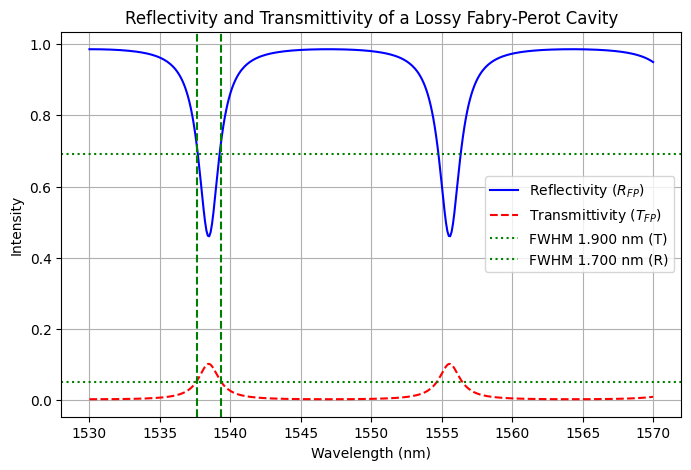

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

wavelengths = np.arange(1530e-9, 1570e-9, 0.1e-9) 
L = 20e-6  
R = 0.9 
T = 1 - R  
n = 3.5  
A = 0.8  

d = (4 * np.pi * n * L) / wavelengths  

R_FP = (R*(1-2*A*np.cos(d)+A**2))/(1-2*R*A*np.cos(d)+(R*A)**2)

T_FP = ((1-R)**2*A)/((1-A*R)**2+4*A*R*np.sin(d/2)**2)

#Calculate FWHM for T and R
peaks, _ = find_peaks(T_FP)

peak_value_R = R_FP[peaks[0]]
half_max_R = peak_value_R / 2 + peak_value_R

peak_value_T = T_FP[peaks[0]]
half_max_T = peak_value_T / 2


left_idx_R = np.max(np.where(R_FP[:peaks[0]] >= half_max_R))
right_idx_R = (np.where(R_FP[peaks[0]:peaks[1]] >= half_max_R))[0][0]+peaks[0]
fwhm_R = wavelengths[right_idx_R] - wavelengths[left_idx_R]

left_idx_T = np.max(np.where(T_FP[:peaks[0]] <= half_max_T))
right_idx_T = np.where(T_FP[peaks[0]:] <= half_max_T)[0][0]+peaks[0]
fwhm_T = np.min(wavelengths[right_idx_T] - wavelengths[left_idx_T])
print(f"FWHM_R: {fwhm_R * 1e9:.3f} nm, FWHM_T: {fwhm_T * 1e9:.3f} nm")



# Plot results
plt.figure(figsize=(8, 5))
plt.plot(wavelengths * 1e9, R_FP, label="Reflectivity ($R_{FP}$)", color='b')
plt.plot(wavelengths * 1e9, T_FP, label="Transmittivity ($T_{FP}$)", color='r', linestyle='dashed')
plt.axvline(x=wavelengths[left_idx_R] * 1e9, color='g', linestyle='--')
plt.axvline(x=wavelengths[right_idx_R] * 1e9, color='g', linestyle='--')
plt.axhline(y=half_max_T, color='g', linestyle=':', label=f"FWHM {fwhm_T * 1e9:.3f} nm (T)")
plt.axhline(y=half_max_R, color='g', linestyle=':', label=f"FWHM {fwhm_R * 1e9:.3f} nm (R)")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Reflectivity and Transmittivity of a Lossy Fabry-Perot Cavity")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
r